In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [23]:
df = pd.read_csv("../data/raw/transactions.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df.head()

,user_id,product_id,timestamp,quantity,price
0,user_60,product_8,2024-10-03 08:39:40.086187,3,64.10
1,user_40,product_4,2024-10-12 08:39:39.711519,2,24.04
2,user_68,product_12,2024-10-18 08:39:40.243016,3,84.92
3,user_4,product_25,2024-10-19 08:39:39.046122,2,80.67
4,user_34,product_23,2024-10-19 08:39:39.592019,1,42.97


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99557 entries, 0 to 99556
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     99557 non-null  object        
 1   product_id  99557 non-null  object        
 2   timestamp   99557 non-null  datetime64[ns]
 3   quantity    99557 non-null  int64         
 4   price       99557 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 3.8+ MB


In [25]:
df.describe()

,timestamp,quantity,price
count,99557,99557.000000,99557.000000
mean,2025-10-25 15:47:23.792276992,1.999769,48.450663
min,2024-10-03 08:39:40.086187,1.000000,11.850000
25%,2025-08-24 08:39:39.880923904,1.000000,26.510000
50%,2025-11-07 08:39:39.937739008,2.000000,43.710000
75%,2026-01-08 08:39:39.370117120,3.000000,64.100000
max,2026-04-14 08:39:40.649101,3.000000,97.290000
std,NaN,0.815551,24.140237


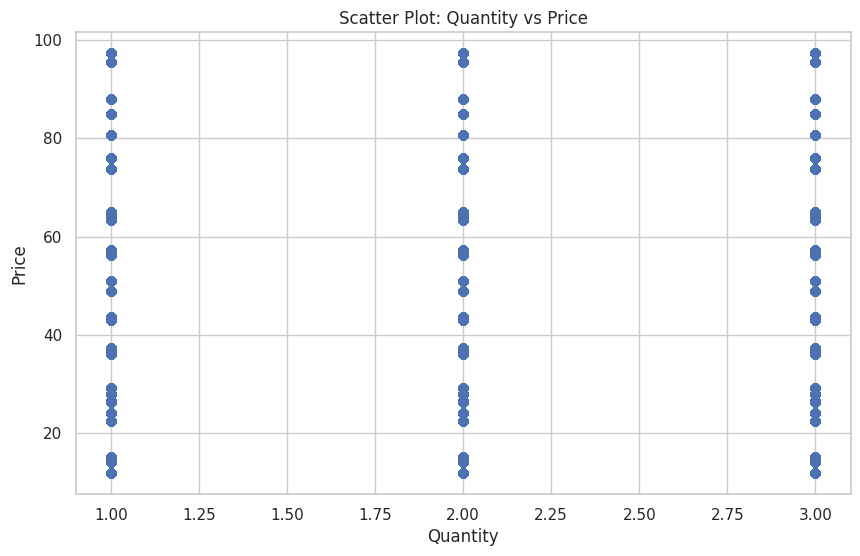

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(df['quantity'], df['price'], alpha=0.5)
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.title('Scatter Plot: Quantity vs Price')
plt.show()

In [27]:
quality_summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "missing_values": [int(df.isna().sum().sum())],
        "duplicate_rows": [int(df.duplicated().sum())],
        "unique_users": [df["user_id"].nunique()],
        "unique_products": [df["product_id"].nunique()],
        "min_timestamp": [df["timestamp"].min()],
        "max_timestamp": [df["timestamp"].max()],
    }
)

quality_summary

,rows,columns,missing_values,duplicate_rows,unique_users,unique_products,min_timestamp,max_timestamp
0,99557,5,0,0,100,30,2024-10-03 08:39:40.086187,2026-04-14 08:39:40.649101


## Quality and consistency checks
This section validates basic dataset quality, price consistency, concentration of interactions, and temporal behavior before feature engineering.

In [28]:
price_consistency = (
    df.groupby("product_id")["price"]
    .nunique()
    .value_counts()
    .rename_axis("distinct_prices_per_product")
    .reset_index(name="product_count")
)

price_consistency

,distinct_prices_per_product,product_count
0,1,30


In [29]:
user_activity = (
    df.groupby("user_id")
    .agg(
        transactions=("product_id", "size"),
        unique_products=("product_id", "nunique"),
        total_quantity=("quantity", "sum"),
        total_spend=("price", lambda series: round(series.sum(), 2)),
    )
    .sort_values("transactions", ascending=False)
)

product_activity = (
    df.groupby("product_id")
    .agg(
        transactions=("user_id", "size"),
        unique_users=("user_id", "nunique"),
        total_quantity=("quantity", "sum"),
    )
    .sort_values("transactions", ascending=False)
)

print("Top 10 users by number of transactions")
display(user_activity.head(10))

print("Top 10 products by number of transactions")
display(product_activity.head(10))

Top 10 users by number of transactions


,transactions,unique_products,total_quantity,total_spend
user_id,,,,
user_34,1189,30,2385,58236.88
user_22,1181,30,2376,56968.01
user_14,1174,30,2324,58044.56
user_58,1172,30,2285,55141.74
user_68,1171,30,2328,55903.68
user_54,1166,30,2369,56694.06
user_51,1165,30,2389,56458.36
user_12,1163,30,2302,56371.59
user_45,1157,30,2337,57009.72


Top 10 products by number of transactions


,transactions,unique_users,total_quantity
product_id,,,
product_29,4530,100,9071
product_28,4436,100,8865
product_27,4284,100,8558
product_26,4241,100,8491
product_25,4135,100,8265
product_24,4115,100,8225
product_23,4036,100,8086
product_22,3825,100,7676
product_21,3807,100,7722


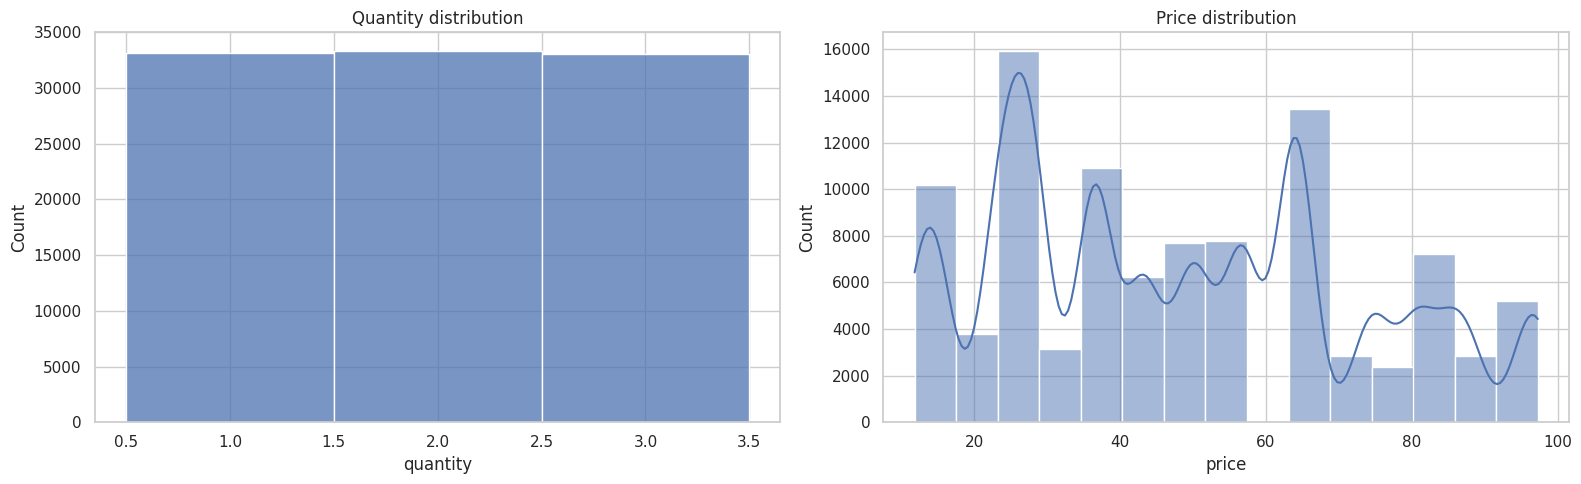

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df["quantity"], bins=3, discrete=True, ax=axes[0])
axes[0].set_title("Quantity distribution")
axes[0].set_xlabel("quantity")

sns.histplot(df["price"], bins=15, kde=True, ax=axes[1])
axes[1].set_title("Price distribution")
axes[1].set_xlabel("price")

plt.tight_layout()
plt.show()

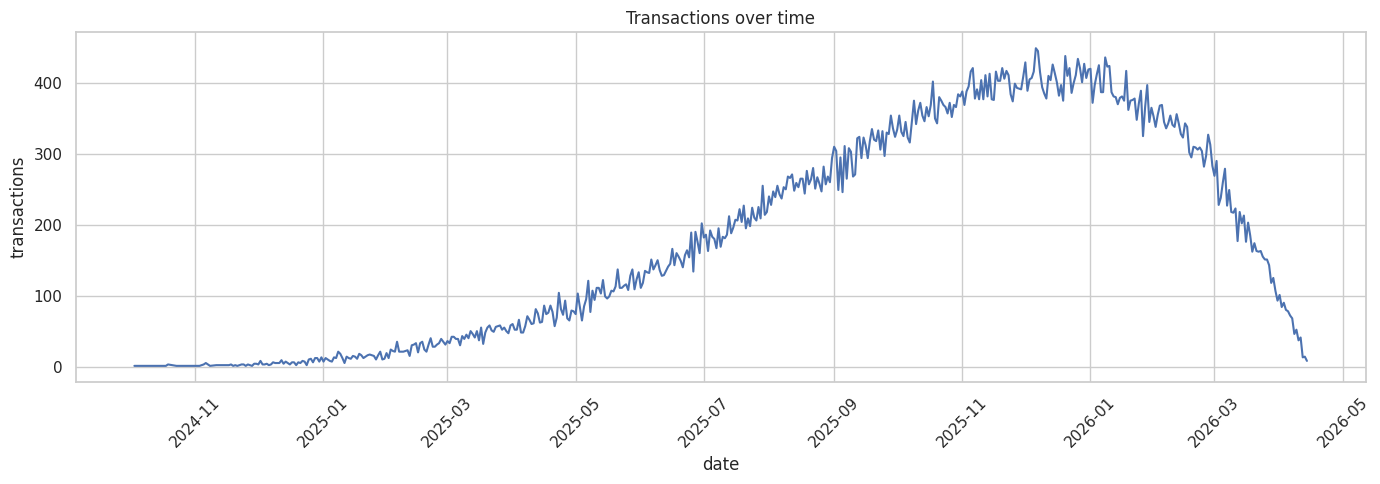

,date,transactions,distinct_users,distinct_products
526,2026-04-10,37,32,21
527,2026-04-11,41,35,22
528,2026-04-12,13,13,11
529,2026-04-13,14,13,12
530,2026-04-14,8,8,7


In [31]:
daily_transactions = (
    df.assign(date=df["timestamp"].dt.date)
    .groupby("date")
    .agg(
        transactions=("user_id", "size"),
        distinct_users=("user_id", "nunique"),
        distinct_products=("product_id", "nunique"),
    )
    .reset_index()
)

daily_transactions["date"] = pd.to_datetime(daily_transactions["date"])

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_transactions, x="date", y="transactions")
plt.title("Transactions over time")
plt.xlabel("date")
plt.ylabel("transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

daily_transactions.tail()

In [32]:
eda_findings = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "missing_values": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "unique_users": int(df["user_id"].nunique()),
    "unique_products": int(df["product_id"].nunique()),
    "min_timestamp": str(df["timestamp"].min()),
    "max_timestamp": str(df["timestamp"].max()),
    "price_consistency_ok": bool((df.groupby("product_id")["price"].nunique() == 1).all()),
    "quantity_mean": float(df["quantity"].mean()),
    "quantity_min": int(df["quantity"].min()),
    "quantity_max": int(df["quantity"].max()),
    "price_mean": float(df["price"].mean()),
    "price_min": float(df["price"].min()),
    "price_max": float(df["price"].max()),
}

eda_findings

{'rows': 99557,
 'columns': 5,
 'missing_values': 0,
 'duplicate_rows': 0,
 'unique_users': 100,
 'unique_products': 30,
 'min_timestamp': '2024-10-03 08:39:40.086187',
 'max_timestamp': '2026-04-14 08:39:40.649101',
 'price_consistency_ok': True,
 'quantity_mean': 1.9997689765661881,
 'quantity_min': 1,
 'quantity_max': 3,
 'price_mean': 48.45066303725504,
 'price_min': 11.85,
 'price_max': 97.29}